In [1]:
import csv
import os
import sys
from pathlib import Path
import numpy as np
import matplotlib
import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import seaborn as sns

SCRIPTS_DIR = Path("../scripts")
rawDATA_DIR = Path("../data/raw")
processedDATA_DIR = Path("../data/processed")
FIG_DIR = Path("../figs")

rawDATA_DIR.mkdir(parents=True, exist_ok=True)
processedDATA_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)

sys.path.append(os.path.abspath("../scripts"))
from utils import *

from matplotlib.backends.backend_pgf import FigureCanvasPgf
matplotlib.backend_bases.register_backend('pdf', FigureCanvasPgf)
matplotlib.rcParams.update({
    "pgf.texsystem": "pdflatex",
    'font.family': 'serif',
    'text.usetex': True,
    "axes.labelsize": 15,
    "xtick.labelsize": 15,
    "ytick.labelsize": 15,
    "legend.fontsize": 15,
    "font.size" : 15,
    "figure.titlesize": 15,
    "pgf.rcfonts": False    
})

# %matplotlib inline

# Processing of data generated with Mathematica

## Murdoch 1987

In [3]:
mH = 1
dH1 = 0
dP1 = 1
dP2 = 8
rH = 33
a = 1

mP = 1/1
dH2 = 1/5

l = dH2 * rH

nm_vect = np.linspace(1,100,100, dtype = np.int32)
unstable_nm_mask = np.where(nm_vect >= 10)
stable_nm_mask = np.where(nm_vect < 10)

fH = (nm_vect*mH)/(nm_vect*mH + dH1)
fP =( nm_vect*mP)/(nm_vect*mP + dP1)
P2_eq_predicted = nm_vect*mH*(fH*rH**(1/nm_vect)-1)/(a*fH)
sH = (nm_vect*mH)/(nm_vect*mH + dH1 + a*P2_eq_predicted)

alphaH_vect = np.zeros((nm_vect.shape[0]))
for j,k_j in enumerate(nm_vect):
    alphaH_vect[j] = np.sum(np.array([sH[j]**i for i in range(k_j)]))
alphaP_vect = np.zeros((nm_vect.shape[0]))
for j,k_j in enumerate(nm_vect):
    alphaP_vect[j] = np.sum(np.array([fP[j]**i for i in range(k_j)]))


H1_eq_predicted = dP2 / (a*(fP)**nm_vect)
H2_eq_predicted = H1_eq_predicted * nm_vect*mH*(sH**(nm_vect-1))/(dH2*alphaH_vect)
P1_eq_predicted = P2_eq_predicted * alphaP_vect*dP2 / (nm_vect*mP*(fP)**(nm_vect-1))

In [4]:
print(H2_eq_predicted[0])
print(H2_eq_predicted[4])
print(H2_eq_predicted[0]/H2_eq_predicted[4])

print(H2_eq_predicted[9])
print(H2_eq_predicted[99])
print(H2_eq_predicted[9]/H2_eq_predicted[99])

80.0
15.744014588914588
5.08129610450998
13.570850731393223
12.03085674128404
1.1280036844611967


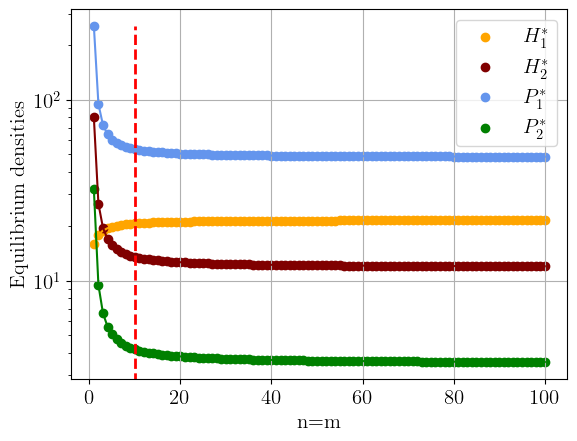

In [5]:
fig = plt.figure()
plt.plot(nm_vect, H1_eq_predicted, color = 'orange')
plt.plot(nm_vect, H2_eq_predicted, color = 'maroon')
plt.plot(nm_vect, P1_eq_predicted, color = 'cornflowerblue')
plt.plot(nm_vect, P2_eq_predicted, color = 'g')
plt.scatter(nm_vect, H1_eq_predicted, color = 'orange', label = "$H_1^*$")
plt.scatter(nm_vect, H2_eq_predicted, color = 'maroon', label = "$H_2^*$")
plt.scatter(nm_vect, P1_eq_predicted, color = 'cornflowerblue', label = "$P_1^*$")
plt.scatter(nm_vect, P2_eq_predicted, color = 'g', label = "$P_2^*$")

plt.vlines(x = 10, ymin = 0, ymax = np.max(P1_eq_predicted), linestyle = "dashed", color = "red", linewidth = 2)
plt.legend()
plt.xlabel("n=m")  
plt.ylabel("Equilibrium densities")
plt.grid(True)
plt.yscale("log")
plt.savefig(FIG_DIR / "Murdoch_equilibrium.pdf")
plt.show()
plt.close()

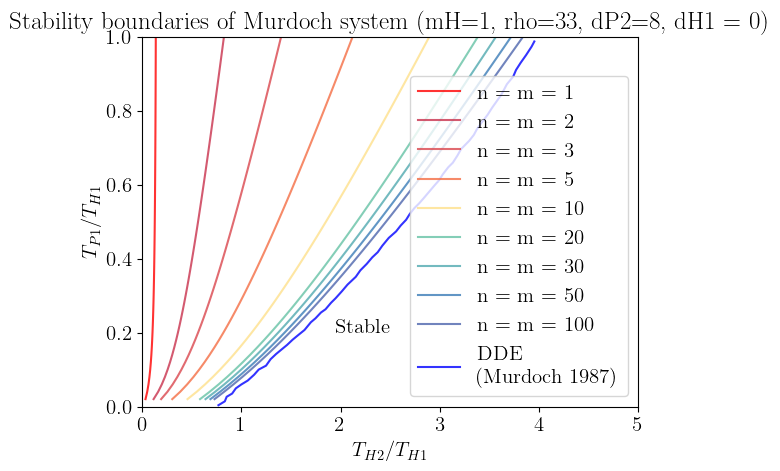

In [6]:
path_folder = rawDATA_DIR / "Murdoch_stability_tH2-tP1_rho_33_dH1_0_dP2_8_dP1_0"
csv_file_nmvalues = "Murdoch_LCT_nmRange.csv"
csv_file_data = "Murdoch_LCT_curves.csv"


fig = plt.figure()
plt.xlabel(r"$T_{H2} / T_{H1}$")  # Maintenant T_H2 est en abscisse
plt.ylabel(r"$T_{P1} / T_{H1}$")  # Maintenant T_P1 est en ordonnée
plt.xlim(0,5)
plt.ylim(0,1)


### LCT Stability curves computed with Mathematica
nmRange = []
with open(path_folder / csv_file_nmvalues, newline="") as csvfile:
    reader = csv.reader(csvfile)
    for i,row in enumerate(reader):
        nmRange.append(int(row[0]))

colors = sns.color_palette("Spectral", as_cmap=False, n_colors = len(nmRange))
colors[0] = "red"
labels = ["n = m = "+ str(nm) for nm in nmRange]

with open(path_folder / csv_file_data, newline="") as csvfile:
    reader = csv.reader(csvfile)
    for i,row in enumerate(reader):
        ntemp = nmRange[i]
        if ntemp not in [1,2,3,5,10,20,30,50,100]: #200 could not be computed in mathematica
            continue
        Courbelimite = []
        for j,col in enumerate(row):
            x,y = extract_curve(col)
            Courbelimite.append((x,y))
        Courbelimite = np.array(Courbelimite)
        plt.plot(Courbelimite[:,0], Courbelimite[:,1], label=labels[i], color = colors[i], alpha = .8) 


### DDE stability curve extracted from Murdoch (1987) with click_points.py
Courbelimite_DDE = []
with open(rawDATA_DIR / "Murdoch_DDE_curve_rho_33_dP2_8.csv", newline="") as csvfile:
    reader = csv.reader(csvfile)
    for i,row in enumerate(reader):
        if i == 0: continue
        x = extract_value(row[0])
        y = extract_value(row[1])
        Courbelimite_DDE.append((x,y))
Courbelimite_DDE = np.array(Courbelimite_DDE)
plt.plot(Courbelimite_DDE[:,0], Courbelimite_DDE[:,1], label="DDE \n (Murdoch 1987)", color = "blue", alpha = .8) 


plt.text(1.95, 0.2, "Stable")

plt.legend()
plt.savefig(FIG_DIR / "Murdoch_stability_diagram.pdf")
plt.title("Stability boundaries of Murdoch system (mH=1, rho=33, dP2=8, dH1 = 0)")
plt.show()
plt.close()

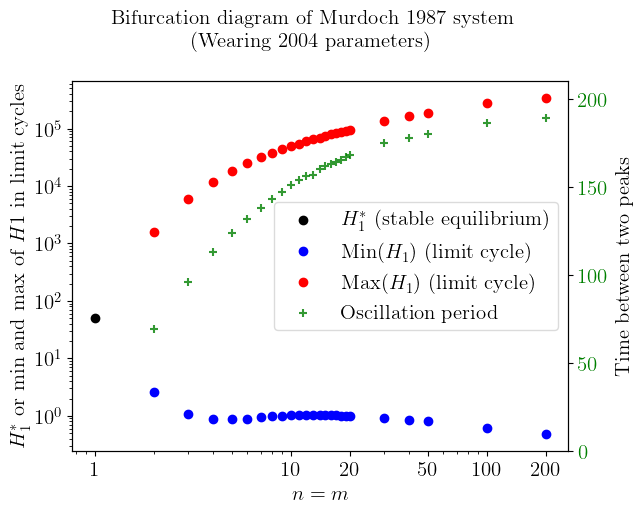

In [30]:
path_folder = rawDATA_DIR / "Murdoch_bifurcation_tH2_5._tP1_20._rho_105._dP2_0.5_dH1_0.00425_dP1_0.1"
csv_file_nmvalues = "nmRange.csv"
csv_file_data = "data.csv"

fig, ax1 = plt.subplots()
ax1.set_xlabel(r"$n = m$")  
ax1.set_ylabel(r"$H_1^*$ or min and max of $H1$ in limit cycles")  

ax2 = ax1.twinx()
ax2.set_ylabel(r"Time between two peaks")  
ax2.tick_params(axis='y', labelcolor="green")

nmValues = []
with open(path_folder / csv_file_nmvalues, newline="") as csvfile:
    reader = csv.reader(csvfile)
    for i,row in enumerate(reader):
        nmValues.append((int(row[0]),int(row[0])))
nmValues_array = np.array(nmValues)

legend_undone1 = True
legend_undone2 = True
legend_undone3 = True

with open(path_folder / csv_file_data, newline="") as csvfile:
    reader = csv.reader(csvfile)
    for i,row in enumerate(reader):
        ntemp = float(row[0])
        mtemp = float(row[1])
        stability = row[3]
        if stability == 'equilibrium':
            eq = float(row[2])
            ax1.scatter(ntemp,eq, color = "black", label = r"$H_1^*$ (stable equilibrium)")
        if stability == 'max':
            max = float(row[2])
            if legend_undone1 :
                ax1.scatter(ntemp,max, color = "red", label = r"Max($H_1$) (limit cycle)")
                legend_undone1 = False
            else:
                ax1.scatter(ntemp,max, color = "red")
        if stability == 'min and time near min':
            min = float(row[2])
            time = float(row[4])
            if legend_undone2 :
                ax1.scatter(ntemp,min, color = "blue",  label = r"Min($H_1$) (limit cycle)")
                legend_undone2 = False
            else:
                ax1.scatter(ntemp,min, color = "blue")
            # fractime_list.append(fractime)
            # CV_list.append(1/np.sqrt(ntemp))
            if legend_undone3 :
                ax2.scatter(ntemp, time, marker = "+", color = "green", alpha = .8, label = "Oscillation period")
                legend_undone3 = False
            else:
                ax2.scatter(ntemp, time, marker = "+", color = "green", alpha = .8)

# leg = ax1.legend()
# # leg2 = ax2.legend()
handles, labels = ax1.get_legend_handles_labels()
handles2, labels2 = ax2.get_legend_handles_labels()
handles.append(handles2[0])
labels.append(labels2)
plt.legend(handles=handles, loc='center right', framealpha = .7) # HANDLES WILL BE USED IN NEXT NOTEBOOK CELL


# plt.legend(leg.get_patches()+leg2.get_handles(), 
#            [text.get_text() for text in leg.get_texts()+leg2.get_texts()], 
#            loc='best', fancybox=False, framealpha=.7)

#ax2.plot(CV_list, fractime_list, color = "green", alpha = .6)
ax1.set_xscale("log")
ax1.set_yscale("log")
ax2.set_ylim(0,210)
ax1.set_xticks([1,10,20,50,100,200],[1,10,20,50,100,200])


plt.savefig(FIG_DIR / "Murdoch_bifurcation_diagram_Wearing-par.pdf")
fig.suptitle("Bifurcation diagram of Murdoch 1987 system \n (Wearing 2004 parameters)", y = 1.03)
plt.show()
plt.close()

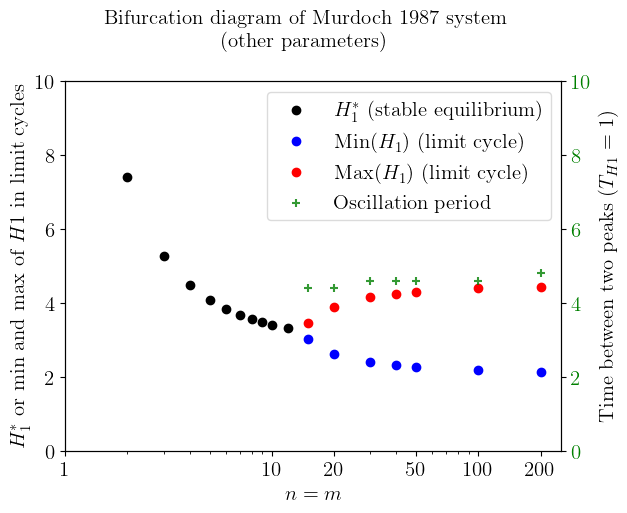

In [17]:
# THIS CELL REQUIRE RUNNING THE PREVIOUS CELL that generated the legend (handles)

path_folder = rawDATA_DIR / "Murdoch_bifurcation_tH2_2._tP1_0.5_rho_33_dP2_8_dH1_0_dP1_1"
csv_file_nmvalues = "nmRange.csv"
csv_file_data = "data.csv"

fig, ax1 = plt.subplots()
ax1.set_xlabel(r"$n = m$")  
ax1.set_ylabel(r"$H_1^*$ or min and max of $H1$ in limit cycles")  

ax2 = ax1.twinx()
ax2.set_ylabel(r"Time between two peaks ($T_{H1} = 1$)")  
ax2.tick_params(axis='y', labelcolor="green")

nmValues = []
with open(path_folder / csv_file_nmvalues, newline="") as csvfile:
    reader = csv.reader(csvfile)
    for i,row in enumerate(reader):
        nmValues.append((int(row[0]),int(row[0])))
nmValues_array = np.array(nmValues)

# fractime_list = [] to plot fractime instead of scatter
# CV_list = []
with open(path_folder / csv_file_data, newline="") as csvfile:
    reader = csv.reader(csvfile)
    for i,row in enumerate(reader):
        ntemp = float(row[0])
        mtemp = float(row[1])
        stability = row[3]
        if stability == 'equilibrium':
            eq = float(row[2])
            ax1.scatter(ntemp,eq, color = "black")
        if stability == 'max':
            max = float(row[2])
            ax1.scatter(ntemp,max, color = "red")
        if stability == 'min and time near min':
            min = float(row[2])
            time = float(row[4])
            ax1.scatter(ntemp,min, color = "blue")
            # fractime_list.append(fractime)
            # CV_list.append(1/np.sqrt(ntemp))
            ax2.scatter(ntemp, time, marker = "+", color = "green", alpha = .8)


plt.legend(handles=handles, loc='best', framealpha = .7) # Require previous cell

#ax2.plot(CV_list, fractime_list, color = "green", alpha = .6)
ax1.set_xscale("log")
ax2.set_ylim(0,10)
ax1.set_ylim(0,10)
ax1.set_xticks([1,10,20,50,100,200],[1,10,20,50,100,200])
#plt.yscale("log")

plt.savefig(FIG_DIR / "Murdoch_bifurcation_diagram_Other-par.pdf")
fig.suptitle("Bifurcation diagram of Murdoch 1987 system \n (other parameters)", y = 1.03)
plt.show()
plt.close()

In [21]:
i=11
i%5

1

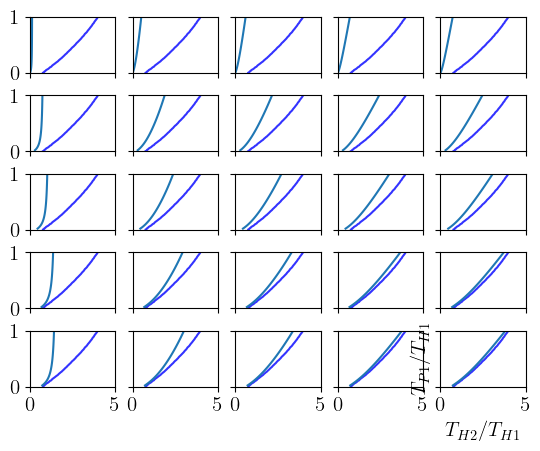

In [27]:
path_folder = rawDATA_DIR / "Murdoch_stability_n_m_tH2-tP1_rho_33_dH1_0_dP2_8_dP1_1"
csv_file_data = "Murdoch_LCT_curves.csv"

### DDE stability curve extracted from Murdoch (1987) with click_points.py
Courbelimite_DDE = []
with open(rawDATA_DIR / "Murdoch_DDE_curve_rho_33_dP2_8.csv", newline="") as csvfile:
    reader = csv.reader(csvfile)
    for i,row in enumerate(reader):
        if i == 0: continue
        x = extract_value(row[0])
        y = extract_value(row[1])
        Courbelimite_DDE.append((x,y))
Courbelimite_DDE = np.array(Courbelimite_DDE)

Courbes_limites = []

with open(path_folder / csv_file_data, newline="") as csvfile:
    reader = csv.reader(csvfile)
    for i,row in enumerate(reader):
        Courbelimite = []
        for j,col in enumerate(row):
            x,y = extract_curve(col)
            Courbelimite.append((x,y))
        Courbes_limites.append(Courbelimite)
Courbes_limites = np.array(Courbes_limites)

fig, axes = plt.subplots(nrows=5, ncols=5, sharex=True, sharey=True)
plt.subplots_adjust( hspace=.4 )

plt.xlabel(r"$T_{H2} / T_{H1}$")  # Maintenant T_H2 est en abscisse
plt.ylabel(r"$T_{P1} / T_{H1}$")  # Maintenant T_P1 est en ordonnée
plt.xlim(0,5)
plt.ylim(0,1)

n_values = [1,5,10,50,100]
for i,ntemp in enumerate(n_values):
    for j,mtemp in enumerate(n_values):
        index = 5*i+j
        axes[i,j].plot(Courbelimite_DDE[:,0], Courbelimite_DDE[:,1], label="DDE \n (Murdoch 1987)", color = "blue", alpha = .8) 
        axes[i,j].plot(Courbes_limites[index,:,0], Courbes_limites[index,:,1])



# ### LCT Stability curves computed with Mathematica
# nmRange = []
# with open(path_folder / csv_file_nmvalues, newline="") as csvfile:
#     reader = csv.reader(csvfile)
#     for i,row in enumerate(reader):
#         nmRange.append(int(row[0]))

# colors = sns.color_palette("Spectral", as_cmap=False, n_colors = len(nmRange))
# colors[0] = "red"
# labels = ["n = m = "+ str(nm) for nm in nmRange]

# with open(path_folder / csv_file_data, newline="") as csvfile:
#     reader = csv.reader(csvfile)
#     for i,row in enumerate(reader):
#         ntemp = nmRange[i]
#         if ntemp not in [1,2,3,5,10,20,30,50,100]: #200 could not be computed in mathematica
#             continue
#         Courbelimite = []
#         for j,col in enumerate(row):
#             x,y = extract_curve(col)
#             Courbelimite.append((x,y))
#         Courbelimite = np.array(Courbelimite)
#         plt.plot(Courbelimite[:,0], Courbelimite[:,1], label=labels[i], color = colors[i], alpha = .8) 

# plt.text(1.95, 0.2, "Stable")

# plt.legend()
# plt.savefig(FIG_DIR / "Murdoch_stability_diagram.pdf")
# plt.title("Stability boundaries of Murdoch system (mH=1, rho=33, dP2=8, dH1 = 0)")
# plt.show()
# plt.close()


# fig, axes = plt.subplots(nrows=4, ncols=4, sharex=True, sharey=True, figsize = (16,9))
# plt.subplots_adjust( hspace=.4 )

# def subplot(n,m,i,j):
#     CourbeLimite = []
#     if n == m:
#         if n==1:
#             with open('CourbeLimitek'+str(n)+'_RH.csv', newline="") as csvfile:
#                 reader = csv.reader(csvfile)
#                 for row in reader:
#                     CourbeLimite.append([float(row[0]), float(row[1])])
#         else : 
#             with open('CourbeLimitek'+str(n)+'.csv', newline="") as csvfile:
#                 reader = csv.reader(csvfile)
#                 for row in reader:
#                     CourbeLimite.append([float(row[0]), float(row[1])])
#     else:
#         with open('CourbeLimiten'+str(n)+'m'+str(m)+'.csv', newline="") as csvfile:
#                 reader = csv.reader(csvfile)
#                 for row in reader:
#                     CourbeLimite.append([float(row[0]), float(row[1])])
#     CourbeLimite = np.array(CourbeLimite)
#     axes[i,j].plot(CourbeLimite[:,0], CourbeLimite[:,1], color = "black")
#     axes[i,j].set_title("n = "+str(n)+", m = "+str(m))
#     axes[i,j].set_xlim(0,5)
#     axes[i,j].text(2.3, 0.3, r"$\sigma^2 tH1 =$"+str(np.round(n/(n*mH)**2,2)))
#     axes[i,j].text(1.3, 0.1, r"$\sigma^2 tP1 (av. 0.5) =$"+str(np.round(m/(m*mP)**2,2)))

# subplot(1,1,0,0)
# subplot(3,1,0,1)
# subplot(5,1,0,2)
# subplot(10,1,0,3)
# subplot(1,3,1,0)
# subplot(1,5,2,0)
# subplot(1,10,3,0)
# subplot(3,3,1,1)
# subplot(5,5,2,2)
# subplot(10,10,3,3)
# subplot(3,5,2,1)
# subplot(5,3,1,2)
# subplot(10,3,1,3)
# #subplot(10,5,2,3)
# subplot(3,10,3,1)
# subplot(5,10,2,3)

# fig.text(0.5, 0.04, r"$T_{H2} / T_{H1}$", ha='center')
# fig.text(0.08, 0.5, r"$T_{P1} / T_{H1}$", va='center', rotation='vertical')

# fig.suptitle("Stability boundaries for mH = 1, rho=33, dP2 = 8, dP1 = 1, dH1 = 0")
# plt.savefig("Stability_boundaries_Murdoch_LCT_n_m.svg")
# plt.show()

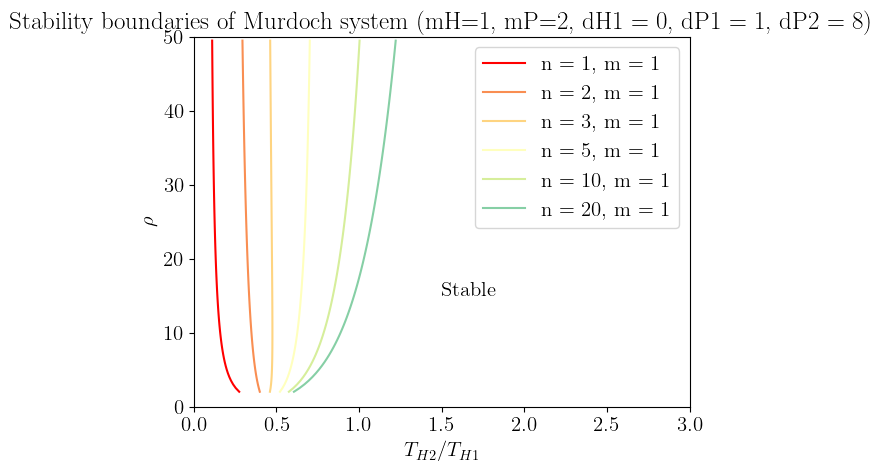

In [20]:
path_folder = rawDATA_DIR / "Murdoch_stability_tH2-rho_mP_2_dP1_1_dH1_0"
csv_file_nmvalues = "nmRange.csv"
csv_file_data = "data.csv"

plt.figure()
plt.xlabel(r"$T_{H2} / T_{H1}$")  # Maintenant T_H2 est en abscisse
plt.ylabel(r"$\rho$")  # Maintenant T_P1 est en ordonnée
plt.xlim(0,3)
plt.ylim(0,50)

nmValues = []
with open(path_folder / csv_file_nmvalues, newline="") as csvfile:
    reader = csv.reader(csvfile)
    for i,row in enumerate(reader):
        nmValues.append((int(row[0]),int(row[1])))

nmValues_array = np.array(nmValues)
# colors = sns.color_palette("magma", as_cmap=False, n_colors = int(len(nmValues)/2))
colors = sns.color_palette("Spectral", as_cmap=False, n_colors = int(len(nmValues)/1.7))
colors[0] = "red"

with open(path_folder / csv_file_data, newline="") as csvfile:
    reader = csv.reader(csvfile)
    for i,row in enumerate(reader):
        ntemp = nmValues[i][0]
        mtemp = nmValues[i][1]
        Courbelimite = []
        for j,col in enumerate(row):
            mathematica_couple = col[1:-1]
            x,y = mathematica_couple.split(',')
            x = float(x)
            y = float(y)
            Courbelimite.append((x,y))
        Courbelimite = np.array(Courbelimite)
        if mtemp == 1:
            plt.plot(Courbelimite[:,0], Courbelimite[:,1], label="n = "+str(ntemp)+", m = "+str(mtemp), 
                     color = colors[i], alpha = 1) 
        else:continue
            # plt.plot(Courbelimite[:,0], Courbelimite[:,1], label="n = "+str(ntemp)+", m = "+str(mtemp), 
            #      color = colors[i-6], alpha = 1, linestyle = "dashed") 

plt.text(1.5, 15, "Stable")

plt.legend()
plt.savefig(FIG_DIR / "Murdoch_stability_fecundity.pdf")
plt.title("Stability boundaries of Murdoch system (mH=1, mP=2, dH1 = 0, dP1 = 1, dP2 = 8)")
plt.show()
plt.close()

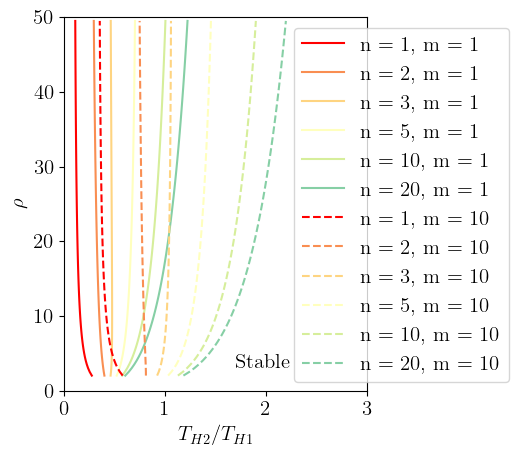

In [5]:
path_folder = rawDATA_DIR / "Murdoch_stability_tH2-rho_mP_2_dP1_1_dH1_0"
csv_file_nmvalues = "nmRange.csv"
csv_file_data = "data.csv"

plt.figure()
plt.xlabel(r"$T_{H2} / T_{H1}$")  # Maintenant T_H2 est en abscisse
plt.ylabel(r"$\rho$")  # Maintenant T_P1 est en ordonnée
plt.xlim(0,3)
plt.ylim(0,50)

nmValues = []
with open(path_folder / csv_file_nmvalues, newline="") as csvfile:
    reader = csv.reader(csvfile)
    for i,row in enumerate(reader):
        nmValues.append((int(row[0]),int(row[1])))

nmValues_array = np.array(nmValues)
# colors = sns.color_palette("magma", as_cmap=False, n_colors = int(len(nmValues)/2))
colors = sns.color_palette("Spectral", as_cmap=False, n_colors = int(len(nmValues)/1.7))
colors[0] = "red"

with open(path_folder / csv_file_data, newline="") as csvfile:
    reader = csv.reader(csvfile)
    for i,row in enumerate(reader):
        ntemp = nmValues[i][0]
        mtemp = nmValues[i][1]
        Courbelimite = []
        for j,col in enumerate(row):
            mathematica_couple = col[1:-1]
            x,y = mathematica_couple.split(',')
            x = float(x)
            y = float(y)
            Courbelimite.append((x,y))
        Courbelimite = np.array(Courbelimite)
        if mtemp == 1:
            plt.plot(Courbelimite[:,0], Courbelimite[:,1], label="n = "+str(ntemp)+", m = "+str(mtemp), 
                     color = colors[i], alpha = 1) 
        else:
            plt.plot(Courbelimite[:,0], Courbelimite[:,1], label="n = "+str(ntemp)+", m = "+str(mtemp), 
                 color = colors[i-6], alpha = 1, linestyle = "dashed") 

plt.text(1.7, 3, "Stable")

plt.legend(bbox_to_anchor=(1.5, 1))
plt.tight_layout()
plt.savefig(FIG_DIR / "Murdoch_stability_fecundity_suppl_fig.pdf")
# plt.title("Stability boundaries of Murdoch system (mH=1, mP=2, dH1 = 0, dP1 = 1, dP2 = 8)")
plt.show()
plt.close()

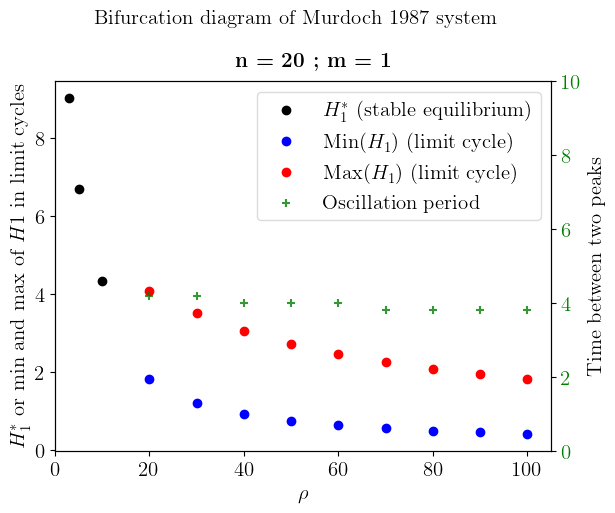

In [29]:
path_folder = rawDATA_DIR / "Murdoch_bifurcation_rho_tH2_1._tP1_1._dP2_8_dH1_0_dP1_1_n_20_m_1"
csv_file_rhovalues = "rhoRange.csv"
csv_file_data = "data.csv"

fig, ax1 = plt.subplots()
ax1.set_xlabel(r"$\rho$")  
ax1.set_ylabel(r"$H_1^*$ or min and max of $H1$ in limit cycles")  

ax2 = ax1.twinx()
ax2.set_ylabel(r"Time between two peaks")  
ax2.tick_params(axis='y', labelcolor="green")

rhoValues = []
with open(path_folder / csv_file_rhovalues, newline="") as csvfile:
    reader = csv.reader(csvfile)
    for i,row in enumerate(reader):
        rhoValues.append((int(row[0]),int(row[0])))
rhoValues_array = np.array(rhoValues)

legend_undone1 = True
legend_undone2 = True
legend_undone3 = True
legend_undone4 = True

with open(path_folder / csv_file_data, newline="") as csvfile:
    reader = csv.reader(csvfile)
    for i,row in enumerate(reader):
        rhotemp = float(row[0])
        stability = row[2]
        if stability == 'equilibrium':
            eq = float(row[1])
            if legend_undone4:
                ax1.scatter(rhotemp,eq, color = "black", label = r"$H_1^*$ (stable equilibrium)")
                legend_undone4 = False
            else:
                ax1.scatter(rhotemp,eq, color = "black")
        if stability == 'max':
            max = float(row[1])
            if legend_undone1 :
                ax1.scatter(rhotemp,max, color = "red", label = r"Max($H_1$) (limit cycle)")
                legend_undone1 = False
            else:
                ax1.scatter(rhotemp,max, color = "red")
        if stability == 'min and time near min':
            min = float(row[1])
            time = float(row[3])
            if legend_undone2 :
                ax1.scatter(rhotemp,min, color = "blue",  label = r"Min($H_1$) (limit cycle)")
                legend_undone2 = False
            else:
                ax1.scatter(rhotemp,min, color = "blue")
            # fractime_list.append(fractime)
            # CV_list.append(1/np.sqrt(ntemp))
            if legend_undone3 :
                ax2.scatter(rhotemp, time, marker = "+", color = "green", alpha = .8, label = "Oscillation period")
                legend_undone3 = False
            else:
                ax2.scatter(rhotemp, time, marker = "+", color = "green", alpha = .8)

# leg = ax1.legend()
# # leg2 = ax2.legend()
handles, labels = ax1.get_legend_handles_labels()
handles2, labels2 = ax2.get_legend_handles_labels()
handles.append(handles2[0])
labels.append(labels2)
plt.legend(handles=handles, loc='upper right', framealpha = .7) # HANDLES WILL BE USED IN NEXT NOTEBOOK CELL


# plt.legend(leg.get_patches()+leg2.get_handles(), 
#            [text.get_text() for text in leg.get_texts()+leg2.get_texts()], 
#            loc='best', fancybox=False, framealpha=.7)

#ax2.plot(CV_list, fractime_list, color = "green", alpha = .6)
# ax1.set_yscale("log")
ax1.set_xlim(0,105)
ax2.set_ylim(0,10)
# ax1.set_xticks([1,10,20,50,100,200],[1,10,20,50,100,200])

plt.text(38,10.4, r"\textbf{n = 20 ; m = 1}")


plt.savefig(FIG_DIR / "Murdoch_rhobifurcation_diagram_n20_m1.pdf")
fig.suptitle("Bifurcation diagram of Murdoch 1987 system", y = 1.03)
plt.show()
plt.close()

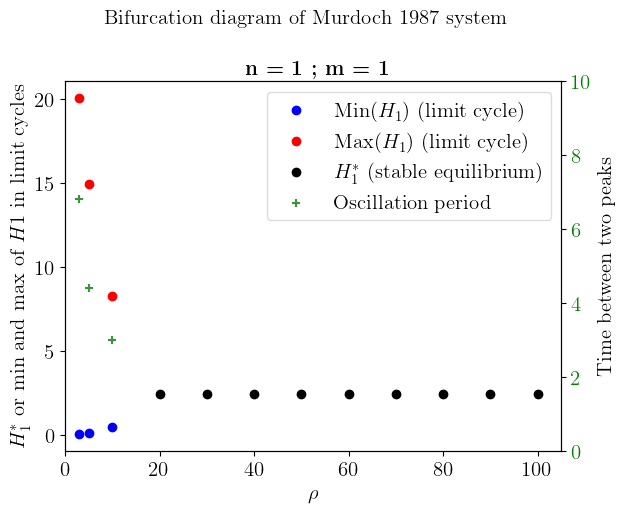

In [27]:
path_folder = rawDATA_DIR / "Murdoch_bifurcation_rho_tH2_0.15_tP1_1._dP2_8_dH1_0_dP1_1_n_1_m_1"
csv_file_rhovalues = "rhoRange.csv"
csv_file_data = "data.csv"

fig, ax1 = plt.subplots()
ax1.set_xlabel(r"$\rho$")  
ax1.set_ylabel(r"$H_1^*$ or min and max of $H1$ in limit cycles")  

ax2 = ax1.twinx()
ax2.set_ylabel(r"Time between two peaks")  
ax2.tick_params(axis='y', labelcolor="green")

rhoValues = []
with open(path_folder / csv_file_rhovalues, newline="") as csvfile:
    reader = csv.reader(csvfile)
    for i,row in enumerate(reader):
        rhoValues.append((int(row[0]),int(row[0])))
rhoValues_array = np.array(rhoValues)

legend_undone1 = True
legend_undone2 = True
legend_undone3 = True
legend_undone4 = True

with open(path_folder / csv_file_data, newline="") as csvfile:
    reader = csv.reader(csvfile)
    for i,row in enumerate(reader):
        rhotemp = float(row[0])
        stability = row[2]
        if stability == 'equilibrium':
            eq = float(row[1])
            if legend_undone4:
                ax1.scatter(rhotemp,eq, color = "black", label = r"$H_1^*$ (stable equilibrium)")
                legend_undone4 = False
            else:
                ax1.scatter(rhotemp,eq, color = "black")
        if stability == 'max':
            max = float(row[1])
            if legend_undone1 :
                ax1.scatter(rhotemp,max, color = "red", label = r"Max($H_1$) (limit cycle)")
                legend_undone1 = False
            else:
                ax1.scatter(rhotemp,max, color = "red")
        if stability == 'min and time near min':
            min = float(row[1])
            time = float(row[3])
            if legend_undone2 :
                ax1.scatter(rhotemp,min, color = "blue",  label = r"Min($H_1$) (limit cycle)")
                legend_undone2 = False
            else:
                ax1.scatter(rhotemp,min, color = "blue")
            # fractime_list.append(fractime)
            # CV_list.append(1/np.sqrt(ntemp))
            if legend_undone3 :
                ax2.scatter(rhotemp, time, marker = "+", color = "green", alpha = .8, label = "Oscillation period")
                legend_undone3 = False
            else:
                ax2.scatter(rhotemp, time, marker = "+", color = "green", alpha = .8)

# leg = ax1.legend()
# # leg2 = ax2.legend()
handles, labels = ax1.get_legend_handles_labels()
handles2, labels2 = ax2.get_legend_handles_labels()
handles.append(handles2[0])
labels.append(labels2)
plt.legend(handles=handles, loc='upper right', framealpha = .7) # HANDLES WILL BE USED IN NEXT NOTEBOOK CELL


# plt.legend(leg.get_patches()+leg2.get_handles(), 
#            [text.get_text() for text in leg.get_texts()+leg2.get_texts()], 
#            loc='best', fancybox=False, framealpha=.7)!!!!b

#ax2.plot(CV_list, fractime_list, color = "green", alpha = .6)
# ax1.set_yscale("log")
ax1.set_xlim(0,105)
ax2.set_ylim(0,10)
# ax1.set_xticks([1,10,20,50,100,200],[1,10,20,50,100,200])

plt.text(38,10.2, r"\textbf{n = 1 ; m = 1}")


plt.savefig(FIG_DIR / "Murdoch_rhobifurcation_diagram_n1_m1.pdf")
fig.suptitle("Bifurcation diagram of Murdoch 1987 system", y = 1.03)
plt.show()
plt.close()

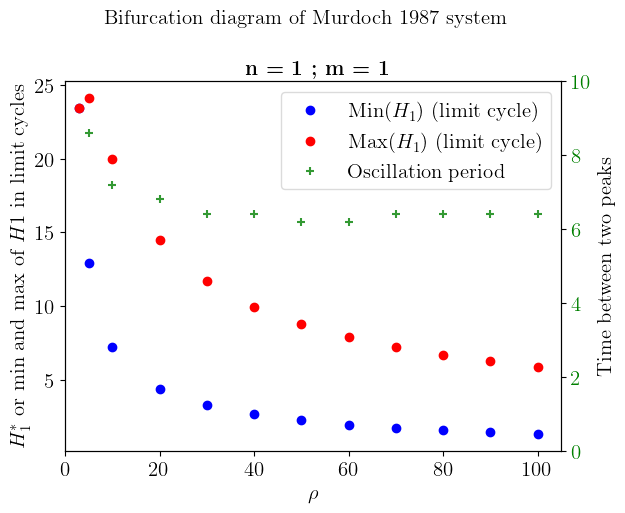

In [32]:
path_folder = rawDATA_DIR / "Murdoch_bifurcation_rho_tH2_2._tP1_1._dP2_8_dH1_0_dP1_1_n_20_m_10"
csv_file_rhovalues = "rhoRange.csv"
csv_file_data = "data.csv"

fig, ax1 = plt.subplots()
ax1.set_xlabel(r"$\rho$")  
ax1.set_ylabel(r"$H_1^*$ or min and max of $H1$ in limit cycles")  

ax2 = ax1.twinx()
ax2.set_ylabel(r"Time between two peaks")  
ax2.tick_params(axis='y', labelcolor="green")

rhoValues = []
with open(path_folder / csv_file_rhovalues, newline="") as csvfile:
    reader = csv.reader(csvfile)
    for i,row in enumerate(reader):
        rhoValues.append((int(row[0]),int(row[0])))
rhoValues_array = np.array(rhoValues)

legend_undone1 = True
legend_undone2 = True
legend_undone3 = True
legend_undone4 = True

with open(path_folder / csv_file_data, newline="") as csvfile:
    reader = csv.reader(csvfile)
    for i,row in enumerate(reader):
        rhotemp = float(row[0])
        stability = row[2]
        if stability == 'equilibrium':
            eq = float(row[1])
            if legend_undone4:
                ax1.scatter(rhotemp,eq, color = "black", label = r"$H_1^*$ (stable equilibrium)")
                legend_undone4 = False
            else:
                ax1.scatter(rhotemp,eq, color = "black")
        if stability == 'max':
            max = float(row[1])
            if legend_undone1 :
                ax1.scatter(rhotemp,max, color = "red", label = r"Max($H_1$) (limit cycle)")
                legend_undone1 = False
            else:
                ax1.scatter(rhotemp,max, color = "red")
        if stability == 'min and time near min':
            min = float(row[1])
            time = float(row[3])
            if legend_undone2 :
                ax1.scatter(rhotemp,min, color = "blue",  label = r"Min($H_1$) (limit cycle)")
                legend_undone2 = False
            else:
                ax1.scatter(rhotemp,min, color = "blue")
            # fractime_list.append(fractime)
            # CV_list.append(1/np.sqrt(ntemp))
            if legend_undone3 :
                ax2.scatter(rhotemp, time, marker = "+", color = "green", alpha = .8, label = "Oscillation period")
                legend_undone3 = False
            else:
                ax2.scatter(rhotemp, time, marker = "+", color = "green", alpha = .8)

# leg = ax1.legend()
# # leg2 = ax2.legend()
handles, labels = ax1.get_legend_handles_labels()
handles2, labels2 = ax2.get_legend_handles_labels()
handles.append(handles2[0])
labels.append(labels2)
plt.legend(handles=handles, loc='upper right', framealpha = .7) # HANDLES WILL BE USED IN NEXT NOTEBOOK CELL


# plt.legend(leg.get_patches()+leg2.get_handles(), 
#            [text.get_text() for text in leg.get_texts()+leg2.get_texts()], 
#            loc='best', fancybox=False, framealpha=.7)!!!!b

#ax2.plot(CV_list, fractime_list, color = "green", alpha = .6)
# ax1.set_yscale("log")
ax1.set_xlim(0,105)
ax2.set_ylim(0,10)
# ax1.set_xticks([1,10,20,50,100,200],[1,10,20,50,100,200])

plt.text(38,10.2, r"\textbf{n = 1 ; m = 1}")


plt.savefig(FIG_DIR / "Murdoch_rhobifurcation_diagram_n20_m10.pdf")
fig.suptitle("Bifurcation diagram of Murdoch 1987 system", y = 1.03)
plt.show()
plt.close()

## Godfray 1989

- 2 compartments added for host

- Pseudointerference

# Equilibrium densities

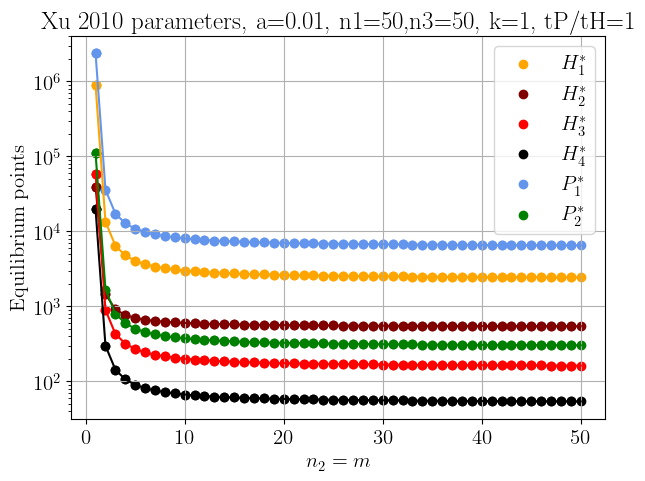

In [37]:
def get_mP(ratioT, dP2, mH1, mH2, mH3, dH4):
    return dH4*dP2*mH1*mH2*mH3 / (ratioT*dH4*dP2*mH1*mH2 + ratioT*dH4*dP2*mH1*mH3 + ratioT*dH4*dP2*mH2*mH3 - dH4*mH1*mH2*mH3 + ratioT*dP2*mH1*mH2*mH3)

"""PARAMETRES"""

mH1 = 0.333333333
mH2 = 0.5
mH3 = 0.3333333333

dH1 = 0
dH2 = 0
dH3 = 0
dH4 = 1
dP1 = 0
dP2 = 2.5

a = .01
beta = 15

n1 = 50
n3 = 50

k = 1
mP = get_mP(1, dP2, mH1, mH2, mH3, dH4)

n2 = np.linspace(1,50,100, dtype = np.int32)
m = np.linspace(1,50,100, dtype = np.int32)

# unstable_nm_mask = np.where(nm_vect >= 10)
# stable_nm_mask = np.where(nm_vect < 10)

"""EQUILIBRES"""

fH1 = (n1*mH1)/(n1*mH1+dH1)
fH3 = (n3*mH3)/(n3*mH3+dH3)
fP = (m*mP)/(m*mP+dP1)

Pieq = n2*mH2*((beta/dH4)**(1/n2))*(fH1**(n1/n2))*(fH3**(n3/n2)) - n2*mH2 - dH2

sH2 = (n2*mH2)/(n2*mH2+dH2+Pieq)

alphaH1 = np.sum(np.array([fH1**i for i in range(0,n1)]))
alphaH2 = []
for j,n in enumerate(n2):
    alphaH2.append(np.sum(np.array([sH2[j]**i for i in range(0,n)])))
alphaH2 = np.array(alphaH2)
alphaH3 = np.sum(np.array([fH3**i for i in range(0,n3)]))
alphaP = []
for j,mi in enumerate(m):
    alphaP.append(np.sum(np.array([fP[j]**i for i in range(0,mi)])))
alphaP = np.array(alphaP)

rho = (beta/dH4)*(fH3**n3)*(fH1**n1)

P2eq = (k/a)*(np.e**(Pieq/k)-1)
H2eq = P2eq * dP2/(Pieq*fP**m)
H1eq = H2eq * ((n2*mH2+dH2+Pieq)/(n1*mH1)) * (alphaH1/alphaH2) * fH1**(1-n1)
H4eq = H1eq * (n1 * mH1 + dH1) / (beta * alphaH1)
#H4eq = H2eq * (n2*mH2/(sH2*alphaH2))*(fH1**(-n1))*(1/beta)
#H4eq = H2eq * n2*mH2*(fH3**n3)*(sH2**n2)/(alphaH2*sH2*dH4)
#H4eq = H2eq * fH3**n3*(n2*mH2*(rho**(1/n2))-n2*mH2)/(dH4*(rho-1))
H3eq = H2eq * (n2*mH2/(n3*mH3))*fH3*(fH1**(-n1))*(fH3**(-n3))*(1/sH2)*(alphaH3/alphaH2)*(dH4/beta)
P1eq = H2eq * Pieq * alphaP/(m*mP+dP1)

fig = plt.figure()
plt.plot(n2, H1eq, color = 'orange')
plt.plot(n2, H2eq, color = 'maroon')
plt.plot(n2, H3eq, color = "red")
plt.plot(n2, H4eq, color = "black")
plt.plot(n2, P1eq, color = 'cornflowerblue')
plt.plot(n2, P2eq, color = 'g')
plt.scatter(n2, H1eq, color = 'orange', label = "$H_1^*$")
plt.scatter(n2, H2eq, color = 'maroon', label = "$H_2^*$")
plt.scatter(n2, H3eq, color = "red", label = "$H_3^*$")
plt.scatter(n2, H4eq, color = 'black', label = "$H_4^*$")
plt.scatter(n2, P1eq, color = 'cornflowerblue', label = "$P_1^*$")
plt.scatter(n2, P2eq, color = 'g', label = "$P_2^*$")
plt.legend()
plt.xlabel(r"$n_2=m$")  
plt.ylabel("Equilibrium points")
plt.grid(True)
plt.yscale("log")
plt.tight_layout()
plt.savefig(FIG_DIR / "Godfray_equilibrium.pdf")
plt.title("Xu 2010 parameters,  a=0.01, n1=50,n3=50, k=1, tP/tH=1")
plt.show()
plt.close()

# Initial stability diagram

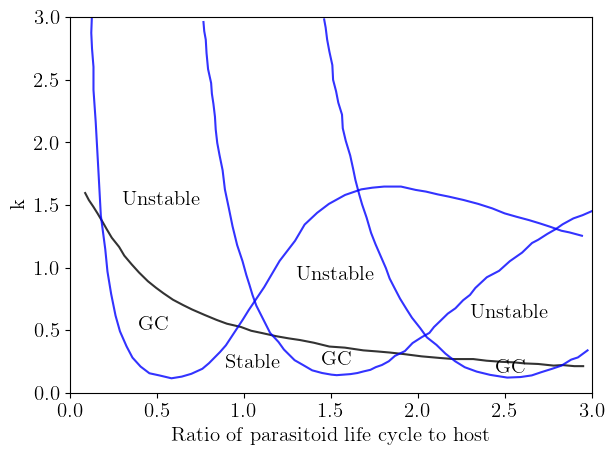

In [36]:
# plt.figure(figsize = (6.4, 9.6))
plt.figure()

### Stability curves for H1,H3 fixed delays, found in Xu 2010 and extracted with click_points.py 
Courbelimite_Xu = []
with open( rawDATA_DIR / "Xu_DDE_VP1.csv", newline="") as csvfile:
    reader = csv.reader(csvfile)
    for i,row in enumerate(reader):
        if i == 0: continue
        x = extract_value(row[0])
        y = extract_value(row[1])
        Courbelimite_Xu.append((x,y))
Courbelimite_Xu = np.array(Courbelimite_Xu)
plt.plot(Courbelimite_Xu[:,0], Courbelimite_Xu[:,1], label=r"Fixed delay for $H_1,H_3$"+"\n (from Xu et al. 2010)", color = "black", alpha = .8) 

Courbelimite_Xu = []
with open( rawDATA_DIR / 'Xu_DDE_VP2.csv', newline="") as csvfile:
    reader = csv.reader(csvfile)
    for i,row in enumerate(reader):
        if i == 0: continue
        x = extract_value(row[0])
        y = extract_value(row[1])
        Courbelimite_Xu.append((x,y))
Courbelimite_Xu = np.array(Courbelimite_Xu)
plt.plot(Courbelimite_Xu[:,0], Courbelimite_Xu[:,1], color = "blue", alpha = .8) 

Courbelimite_Xu = []
with open( rawDATA_DIR / 'Xu_DDE_VP3.csv', newline="") as csvfile:
    reader = csv.reader(csvfile)
    for i,row in enumerate(reader):
        if i == 0: continue
        x = extract_value(row[0])
        y = extract_value(row[1])
        Courbelimite_Xu.append((x,y))
Courbelimite_Xu = np.array(Courbelimite_Xu)
plt.plot(Courbelimite_Xu[:,0], Courbelimite_Xu[:,1], color = "blue", alpha = .8) 

Courbelimite_Xu = []
with open( rawDATA_DIR / 'Xu_DDE_VP4.csv', newline="") as csvfile:
    reader = csv.reader(csvfile)
    for i,row in enumerate(reader):
        if i == 0: continue
        x = extract_value(row[0])
        y = extract_value(row[1])
        Courbelimite_Xu.append((x,y))
Courbelimite_Xu = np.array(Courbelimite_Xu)
plt.plot(Courbelimite_Xu[:,0], Courbelimite_Xu[:,1], color = "blue", alpha = .8) 

plt.text(0.3, 1.5, "Unstable")
plt.text(1.3, 0.9, "Unstable")
plt.text(2.3, 0.6, "Unstable")
plt.text(0.4, 0.5, "GC")
plt.text(1.45, 0.22, "GC")
plt.text(2.45, 0.16, "GC")
plt.text(0.9, 0.2, "Stable")


plt.xlabel("Ratio of parasitoid life cycle to host")
plt.ylabel("k")
plt.xlim(0,3)
plt.ylim(0,3)
plt.tight_layout()
plt.savefig(FIG_DIR / "Godfray_stability_diagram.pdf")
plt.show()
plt.close()

### Effect of n1,n3 on GC dynamics

4.410000000000033
2.6500000000000417
1.9900000000000195


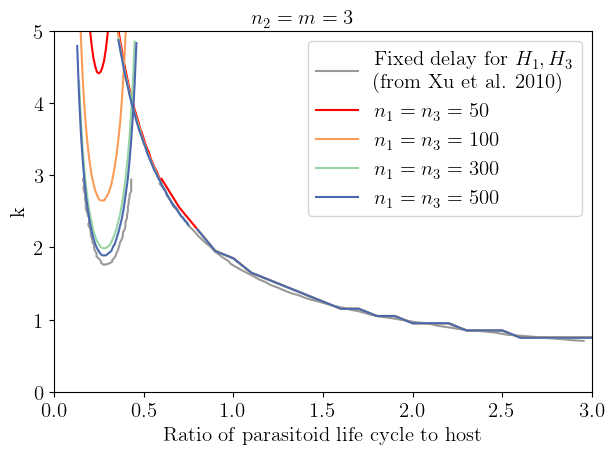

In [5]:
path_folder1a = rawDATA_DIR / "Godfray_VP_n1_50_n2_3_n3_50_m_3_other_Xu_parameters_low_ratioT_values"
path_folder1b = rawDATA_DIR / "Godfray_VP_n1_50_n2_3_n3_50_m_3_other_Xu_parameters_high_ratioT_values"

path_folder2a = rawDATA_DIR / "Godfray_VP_n1_100_n2_3_n3_100_m_3_other_Xu_parameters_low_ratioT_values"
path_folder2b = rawDATA_DIR / "Godfray_VP_n1_100_n2_3_n3_100_m_3_other_Xu_parameters_high_ratioT_values"

path_folder3a = rawDATA_DIR / "Godfray_VP_n1_300_n2_3_n3_300_m_3_other_Xu_parameters_low_ratioT_values"
path_folder3b = rawDATA_DIR / "Godfray_VP_n1_300_n2_3_n3_300_m_3_other_Xu_parameters_high_ratioT_values"

path_folder4a = rawDATA_DIR / "Godfray_VP_n1_500_n2_3_n3_500_m_3_other_Xu_parameters_low_ratioT_values"
path_folder4b = rawDATA_DIR / "Godfray_VP_n1_500_n2_3_n3_500_m_3_other_Xu_parameters_high_ratioT_values"

csv_file_data = "data.csv"

# plt.figure(figsize = (6.4, 9.6))
plt.figure()

### Stability curves for H1,H3 fixed delays, n2=m=3 found in Xu 2010 and extracted with click_points.py 
Courbelimite_Xu = []
with open( rawDATA_DIR / "Xu_n3_VP1.csv", newline="") as csvfile:
    reader = csv.reader(csvfile)
    for i,row in enumerate(reader):
        if i == 0: continue
        x = extract_value(row[0])
        y = extract_value(row[1])
        Courbelimite_Xu.append((x,y))
Courbelimite_Xu = np.array(Courbelimite_Xu)
plt.plot(Courbelimite_Xu[:,0], Courbelimite_Xu[:,1], label=r"Fixed delay for $H_1,H_3$"+"\n (from Xu et al. 2010)", color = "grey", alpha = .8) 

Courbelimite_Xu = []
with open( rawDATA_DIR / 'Xu_n3_VP2.csv', newline="") as csvfile:
    reader = csv.reader(csvfile)
    for i,row in enumerate(reader):
        if i == 0: continue
        x = extract_value(row[0])
        y = extract_value(row[1])
        Courbelimite_Xu.append((x,y))
Courbelimite_Xu = np.array(Courbelimite_Xu)
plt.plot(Courbelimite_Xu[:,0], Courbelimite_Xu[:,1], color = "grey", alpha = .8) 



### Stability curves generated by Godfray_Script_stability_diagram_effect_of_n1n3
colors = sns.color_palette("Spectral", as_cmap=False, n_colors = 21)
colors[0] = "red"
# colors.insert(0,"red")

# n1,n3 = 50
t_vals, k_vals, GridVPs = extractVPs_Godfray(path = path_folder1a / csv_file_data, nb_of_VP = int(2))
k_roots0 = find_k_roots(t_vals, k_vals, GridVPs, 0)
k_roots1 = find_k_roots(t_vals, k_vals, GridVPs, 1)
print(np.nanmin(k_roots1), )
plt.plot(t_vals, k_roots0, color = colors[0])
plt.plot(t_vals, k_roots1, color = colors[0])

t_vals, k_vals, GridVPs = extractVPs_Godfray(path = path_folder1b / csv_file_data, nb_of_VP = int(2))
k_roots0 = find_k_roots(t_vals, k_vals, GridVPs, 0)
k_roots1 = find_k_roots(t_vals, k_vals, GridVPs, 1)
plt.plot(t_vals, k_roots0, label=r"$n_1=n_3=50$", color = colors[0])
plt.plot(t_vals, k_roots1, color = colors[0])


# n1,n3 = 100
t_vals, k_vals, GridVPs = extractVPs_Godfray(path = path_folder2a / csv_file_data, nb_of_VP = int(2))
k_roots0 = find_k_roots(t_vals, k_vals, GridVPs, 0)
k_roots1 = find_k_roots(t_vals, k_vals, GridVPs, 1)
print(np.nanmin(k_roots1))
plt.plot(t_vals, k_roots0, color = colors[5])
plt.plot(t_vals, k_roots1, color = colors[5])

t_vals, k_vals, GridVPs = extractVPs_Godfray(path = path_folder2b / csv_file_data, nb_of_VP = int(2))
k_roots0 = find_k_roots(t_vals, k_vals, GridVPs, 0)
k_roots1 = find_k_roots(t_vals, k_vals, GridVPs, 1)
plt.plot(t_vals, k_roots0, label=r"$n_1=n_3=100$", color = colors[5])
plt.plot(t_vals, k_roots1, color = colors[5])



# n1,n3 = 300
t_vals, k_vals, GridVPs = extractVPs_Godfray(path = path_folder3a / csv_file_data, nb_of_VP = int(2))
k_roots0 = find_k_roots(t_vals, k_vals, GridVPs, 0)
k_roots1 = find_k_roots(t_vals, k_vals, GridVPs, 1)
print(np.nanmin(k_roots1))
plt.plot(t_vals, k_roots0, color = colors[15])
plt.plot(t_vals, k_roots1, color = colors[15])

t_vals, k_vals, GridVPs = extractVPs_Godfray(path = path_folder3b / csv_file_data, nb_of_VP = int(2))
k_roots0 = find_k_roots(t_vals, k_vals, GridVPs, 0)
k_roots1 = find_k_roots(t_vals, k_vals, GridVPs, 1)
plt.plot(t_vals, k_roots0, label=r"$n_1=n_3=300$", color = colors[15])
plt.plot(t_vals, k_roots1, color = colors[15])



#n1,n3 = 500
t_vals, k_vals, GridVPs = extractVPs_Godfray(path = path_folder4a / csv_file_data, nb_of_VP = int(2))
k_roots0 = find_k_roots(t_vals, k_vals, GridVPs, 0)
k_roots1 = find_k_roots(t_vals, k_vals, GridVPs, 1)
plt.plot(t_vals, k_roots0, color = colors[20])
plt.plot(t_vals, k_roots1, color = colors[20])

t_vals, k_vals, GridVPs = extractVPs_Godfray(path = path_folder4b / csv_file_data, nb_of_VP = int(2))
k_roots0 = find_k_roots(t_vals, k_vals, GridVPs, 0)
k_roots1 = find_k_roots(t_vals, k_vals, GridVPs, 1)
plt.plot(t_vals, k_roots0, label=r"$n_1=n_3=500$", color = colors[20])
plt.plot(t_vals, k_roots1, color = colors[20])

plt.text(1.1,5.1, r"$n_2 = m = 3$")

plt.legend()
plt.xlabel("Ratio of parasitoid life cycle to host")
plt.ylabel("k")
plt.xlim(0,3)
plt.ylim(0,5)
plt.tight_layout()
plt.savefig(FIG_DIR / "Godfray_effect-of-n1n3.pdf")
plt.show()
plt.close()

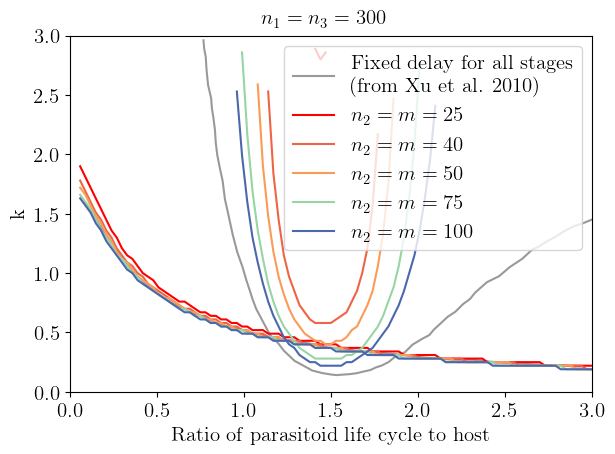

In [6]:
path_folder1 = rawDATA_DIR / "Godfray_VP_n1_300_n2_25_n3_300_m_25_other_Xu_parameters"
path_folder2 = rawDATA_DIR / "Godfray_VP_n1_300_n2_50_n3_300_m_50_other_Xu_parameters"
path_folder3 = rawDATA_DIR / "Godfray_VP_n1_300_n2_75_n3_300_m_75_other_Xu_parameters"
path_folder4 = rawDATA_DIR / "Godfray_VP_n1_300_n2_100_n3_300_m_100_other_Xu_parameters"
path_folder5 = rawDATA_DIR / "Godfray_VP_n1_300_n2_40_n3_300_m_40_other_Xu_parameters"


csv_file_data = "data.csv"

# plt.figure(figsize = (6.4, 9.6))
plt.figure()

### Stability curves for H1,H3 fixed delays, n2=m=3 found in Xu 2010 and extracted with click_points.py 
Courbelimite_Xu = []
with open( rawDATA_DIR / "Xu_DDE_VP1.csv", newline="") as csvfile:
    reader = csv.reader(csvfile)
    for i,row in enumerate(reader):
        if i == 0: continue
        x = extract_value(row[0])
        y = extract_value(row[1])
        Courbelimite_Xu.append((x,y))
Courbelimite_Xu = np.array(Courbelimite_Xu)
plt.plot(Courbelimite_Xu[:,0], Courbelimite_Xu[:,1], label=r"Fixed delay for all stages" +"\n (from Xu et al. 2010)", color = "grey", alpha = .8) 

Courbelimite_Xu = []
with open( rawDATA_DIR / 'Xu_DDE_VP3.csv', newline="") as csvfile:
    reader = csv.reader(csvfile)
    for i,row in enumerate(reader):
        if i == 0: continue
        x = extract_value(row[0])
        y = extract_value(row[1])
        Courbelimite_Xu.append((x,y))
Courbelimite_Xu = np.array(Courbelimite_Xu)
plt.plot(Courbelimite_Xu[:,0], Courbelimite_Xu[:,1], color = "grey", alpha = .8) 

### Stability curves generated by Godfray_Script_stability_diagram_effect_of_n1n3
colors = sns.color_palette("Spectral", as_cmap=False, n_colors = 21)
colors[0] = "red"
# colors.insert(0,"red")

# n2,m = 25
t_vals, k_vals, GridVPs = extractVPs_Godfray(path = path_folder1 / csv_file_data, nb_of_VP = int(4))
k_roots0 = find_k_roots(t_vals, k_vals, GridVPs, 0)
k_roots1 = find_k_roots(t_vals, k_vals, GridVPs, 2)
plt.plot(t_vals, k_roots0, color = colors[0])
plt.plot(t_vals, k_roots1, color = colors[0], label=r"$n_2=m=25$")

# n2,m = 40
t_vals, k_vals, GridVPs = extractVPs_Godfray(path = path_folder5 / csv_file_data, nb_of_VP = int(4))
k_roots0 = find_k_roots(t_vals, k_vals, GridVPs, 0)
k_roots1 = find_k_roots(t_vals, k_vals, GridVPs, 2)
plt.plot(t_vals, k_roots0, color = colors[3])
plt.plot(t_vals, k_roots1, color = colors[3], label=r"$n_2=m=40$")

# n2,m = 50
t_vals, k_vals, GridVPs = extractVPs_Godfray(path = path_folder2 / csv_file_data, nb_of_VP = int(4))
k_roots0 = find_k_roots(t_vals, k_vals, GridVPs, 0)
k_roots1 = find_k_roots(t_vals, k_vals, GridVPs, 2)
plt.plot(t_vals, k_roots0, color = colors[5])
plt.plot(t_vals, k_roots1, color = colors[5], label=r"$n_2=m=50$")

# n2,m = 75
t_vals, k_vals, GridVPs = extractVPs_Godfray(path = path_folder3 / csv_file_data, nb_of_VP = int(4))
k_roots0 = find_k_roots(t_vals, k_vals, GridVPs, 0)
k_roots1 = find_k_roots(t_vals, k_vals, GridVPs, 2)
plt.plot(t_vals, k_roots0, color = colors[15])
plt.plot(t_vals, k_roots1, color = colors[15], label=r"$n_2=m=75$")

# n2,m = 100
t_vals, k_vals, GridVPs = extractVPs_Godfray(path = path_folder4 / csv_file_data, nb_of_VP = int(4))
k_roots0 = find_k_roots(t_vals, k_vals, GridVPs, 0)
k_roots1 = find_k_roots(t_vals, k_vals, GridVPs, 2)
plt.plot(t_vals, k_roots0, color = colors[20])
plt.plot(t_vals, k_roots1, color = colors[20], label=r"$n_2=m=100$")

plt.text(1.1,3.1, r"$n_1 = n_3 = 300$")


plt.legend(loc = 'upper right')
plt.xlabel("Ratio of parasitoid life cycle to host")
plt.ylabel("k")
plt.xlim(0,3)
plt.ylim(0,3)
plt.tight_layout()
plt.savefig(FIG_DIR / "Godfray_effect-of-n2m.pdf")
plt.show()
plt.close()

In [ ]:
# def find_k_roots(t_values, k_values, GridVPs, index_VP): # index_VP : ith VP
#     k_roots = np.zeros(t_values.shape[0])
#     for i,t in enumerate(t_values):
#         signchange = np.diff(np.sign(GridVPs[i,:,index_VP])) != 0
#         if np.sum(signchange) == 0 :
#             continue
#         if np.sum(signchange) > 1 : 
#             print("ERROR")
#             break
#         k_roots[i] = k_values[signchange][0] - 0.05 # k root is somewhere between x and x+1 knowing that here the step betweens x is 0.1
#     k_roots[k_roots == 0.] = np.nan # Removing cases where no k root for given t
#     return k_roots


# # plt.figure(figsize = (6.4, 9.6))
# plt.figure()

# ### Stability curves for H1,H3 fixed delays, n2=m=3 found in Xu 2010 and extracted with click_points.py 
# Courbelimite_Xu = []
# with open( rawDATA_DIR / "Xu_DDE_VP1.csv", newline="") as csvfile:
#     reader = csv.reader(csvfile)
#     for i,row in enumerate(reader):
#         if i == 0: continue
#         x = extract_value(row[0])
#         y = extract_value(row[1])
#         Courbelimite_Xu.append((x,y))
# Courbelimite_Xu = np.array(Courbelimite_Xu)
# plt.plot(Courbelimite_Xu[:,0], Courbelimite_Xu[:,1], label=r"Fixed delay for $H_1,H_3$"+"\n (from Xu et al. 2010)", color = "grey", alpha = .8) 

# Courbelimite_Xu = []
# with open( rawDATA_DIR / 'Xu_DDE_VP3.csv', newline="") as csvfile:
#     reader = csv.reader(csvfile)
#     for i,row in enumerate(reader):
#         if i == 0: continue
#         x = extract_value(row[0])
#         y = extract_value(row[1])
#         Courbelimite_Xu.append((x,y))
# Courbelimite_Xu = np.array(Courbelimite_Xu)
# plt.plot(Courbelimite_Xu[:,0], Courbelimite_Xu[:,1], color = "grey", alpha = .8) 



# colors = sns.color_palette("Spectral", as_cmap=False, n_colors = 10)

# k_values = np.arange(1,50,1)/10
# t_values = np.arange(1,30,1)/10

# MeshVP = np.zeros((50,30,4)) #k in dim0, t in dim1, nth vp in dim2
# with open('Table_Xu_n1_300_n2_300.csv', newline="") as csvfile:
#     reader = csv.reader(csvfile)
#     for i,row in enumerate(reader):
#         for j,col in enumerate(row):
#             MeshVP[i,j] = extract_array(col)
# k_roots0 = find_k_roots(t_values, k_values, MeshVP, 3)
# k_roots2 = find_k_roots(t_values, k_values, MeshVP, 1)
# plt.plot(t_values, k_roots0, label = "n2=m=300", color = colors[9])
# plt.plot(t_values, k_roots2, color = colors[9])

# MeshVP = np.zeros((50,30,4)) #k in dim0, t in dim1, nth vp in dim2
# with open('Table_Xu_n1_300_n2_100.csv', newline="") as csvfile:
#     reader = csv.reader(csvfile)
#     for i,row in enumerate(reader):
#         for j,col in enumerate(row):
#             MeshVP[i,j] = extract_array(col)
# k_roots2 = find_k_roots(t_values, k_values, MeshVP, 3)
# k_roots0 = find_k_roots(t_values, k_values, MeshVP, 1)
# plt.plot(t_values, k_roots0, label="n2=m=100", color = colors[7])
# plt.plot(t_values, k_roots2, color = colors[7])

# MeshVP = np.zeros((50,30,4)) #k in dim0, t in dim1, nth vp in dim2
# with open('Table_Xu_n1_300_n2_50.csv', newline="") as csvfile:
#     reader = csv.reader(csvfile)
#     for i,row in enumerate(reader):
#         for j,col in enumerate(row):
#             MeshVP[i,j] = extract_array(col)
# k_roots2 = find_k_roots(t_values, k_values, MeshVP, 3)
# k_roots0 = find_k_roots(t_values, k_values, MeshVP, 1)
# plt.plot(t_values, k_roots0, label = "n2=m=50", color = colors[0])
# plt.plot(t_values, k_roots2, color = colors[0])


# plt.legend(loc = 'upper left')
# plt.xlabel("Ratio of parasitoid life cycle to host")
# plt.ylabel("k")
# plt.xlim(0,3)
# plt.ylim(0,3)
# plt.savefig(FIG_DIR / "Godfray_effect-of-n2m_old_version.pdf")
# plt.show()
# plt.close()

## Equivalence k-n

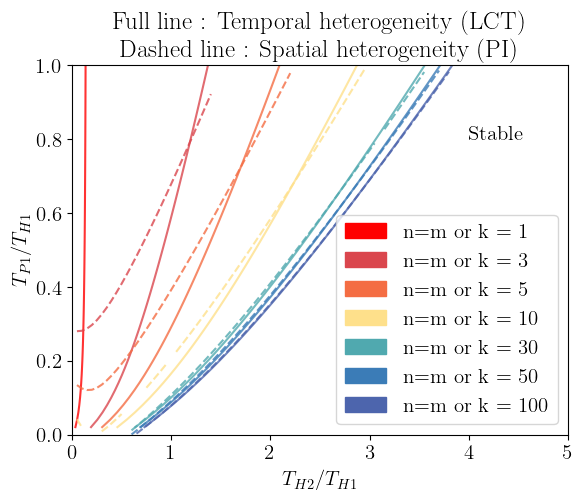

In [7]:
path_folderLCT = rawDATA_DIR / "Murdoch_stability_HET_LCTplot_rho_33_dH1_0_dP2_8_dP1_0.1"
csv_file_nmvaluesLCT = "Murdoch_LCT_nmRange.csv"
csv_file_dataLCT = "Murdoch_LCT_curves.csv"

path_folderPI = rawDATA_DIR / "Murdoch_stability_HET_PIplot_"
csv_file_dataPI = "data.csv"




fig = plt.figure()
plt.xlabel(r"$T_{H2} / T_{H1}$")  # Maintenant T_H2 est en abscisse
plt.ylabel(r"$T_{P1} / T_{H1}$")  # Maintenant T_P1 est en ordonnée
plt.xlim(0,5)
plt.ylim(0,1)

nmPlotted = [1,3,5,10,30,50,100]

### LCT Stability curves computed with Mathematica
nmRange = []
with open(path_folderLCT / csv_file_nmvaluesLCT, newline="") as csvfile:
    reader = csv.reader(csvfile)
    for i,row in enumerate(reader):
        nmRange.append(int(row[0]))

colors = sns.color_palette("Spectral", as_cmap=False, n_colors = len(nmRange))
colors[0] = "red"
labels = ["n=m or k = "+ str(nm) for nm in nmRange]
patches = []
for i,colori in enumerate(colors):
    ntemp = nmRange[i]
    if ntemp not in nmPlotted:continue
    patches.append(mpatches.Patch(color=colori, label=labels[i]))

with open(path_folderLCT / csv_file_dataLCT, newline="") as csvfile:
    reader = csv.reader(csvfile)
    for i,row in enumerate(reader):
        ntemp = nmRange[i]
        if ntemp not in nmPlotted:continue
        Courbelimite = []
        for j,col in enumerate(row):
            x,y = extract_curve(col)
            Courbelimite.append((x,y))
        Courbelimite = np.array(Courbelimite)
        plt.plot(Courbelimite[:,0], Courbelimite[:,1], label=labels[i], color = colors[i], alpha = .8) 


with open(path_folderPI / csv_file_dataPI, newline="") as csvfile:
    reader = csv.reader(csvfile)
    for i,row in enumerate(reader):
        ntemp = nmRange[i]
        if ntemp not in nmPlotted:continue
        Courbelimite = []
        for j,col in enumerate(row):
            x,y = extract_curve(col)
            if (x,y) == (0,0):continue
            else:
                Courbelimite.append((x,y))
        Courbelimite = np.array(Courbelimite)
        plt.plot(Courbelimite[:,0], Courbelimite[:,1], color = colors[i], alpha = .8, linestyle = "dashed") 

plt.text(4, 0.8, "Stable")

# plt.legend(bbox_to_anchor=(1, 0.8))
plt.legend(handles = patches)
plt.title("Full line : Temporal heterogeneity (LCT) \n Dashed line : Spatial heterogeneity (PI)")


plt.savefig(FIG_DIR / "Equivalence_k_n.pdf")
plt.show()
plt.close()
